In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("House Price Prediction Dataset.csv")

# Display first 5 rows
df.head()


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [3]:
print("Shape:", df.shape)

# Column names and data types
df.info()

Shape: (2000, 10)
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 184.3 KB


In [4]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [5]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


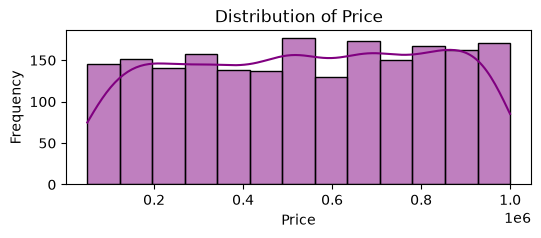

In [6]:
plt.figure(figsize=(6, 2))
sns.histplot(df["Price"], kde=True,color="purple")
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

## Exploratory Data Analysis (EDA)

In this section, we perform Exploratory Data Analysis (EDA) to understand the dataset.

The following steps are performed:
- Check for missing/null values
- Generate descriptive statistics
- Analyze the distribution of the target variable (`price`)
- Identify potential outliers using a boxplot

## Feature Selection Discussion

The target variable for this project is **Price**. The remaining columns are potential predictor features.

### Selected Predictor Features

- **Area:** Larger properties are generally more expensive, so Area is likely to be an important predictor.
- **Bedrooms:** The number of bedrooms can affect the value and price of a property.
- **Bathrooms:** Properties with more bathrooms may have higher prices.
- **Floors:** The number of floors may influence the property's value.
- **YearBuilt:** The age of a property can affect its price. Newer properties may have higher prices.
- **Location:** Location can strongly influence property prices because properties in desirable areas may cost more.
- **Condition:** The condition of the property can affect its market value.
- **Garage:** Availability and size of a garage may influence the property price.

### Feature to Exclude

- **Id:** This is an identifier and does not provide meaningful information for predicting price. Therefore, it should not be used as a predictor.

### Conclusion

The potential predictors of **Price** are:

**Area, Bedrooms, Bathrooms, Floors, YearBuilt, Location, Condition, and Garage.**

The **Id** column should be excluded because it is only used to identify individual records.

In [7]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [8]:
df = pd.get_dummies(
    df,
    columns=["Location", "Condition"],
    drop_first=True
)

df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Garage,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor
0,1,1360,5,4,3,1970,No,149919,False,False,False,False,False,False
1,2,4272,5,4,3,1958,No,424998,False,False,False,False,False,False
2,3,3592,2,2,3,1938,No,266746,False,False,False,False,True,False
3,4,966,4,2,2,1902,Yes,244020,False,True,False,True,False,False
4,5,4926,1,4,2,1975,Yes,636056,False,False,False,True,False,False


In [9]:
# Calculate correlation matrix
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor
Id,1.000000,-0.012966,-0.016393,-0.025433,-0.002025,0.008840,-0.025643,0.006647,-0.044954,0.016093,-0.007459,-0.025798,0.034609
Area,-0.012966,1.000000,0.047523,0.021881,0.017749,-0.011609,0.001542,-0.017328,0.003404,0.000010,0.012805,0.001289,-0.003387
Bedrooms,-0.016393,0.047523,1.000000,-0.011990,0.010435,-0.014125,-0.003471,-0.011276,-0.010409,0.025640,0.002541,-0.008847,0.010673
Bathrooms,-0.025433,0.021881,-0.011990,1.000000,0.029089,-0.000839,-0.015737,-0.020028,-0.000904,-0.007326,-0.029646,0.021735,0.013355
Floors,-0.002025,0.017749,0.010435,0.029089,1.000000,-0.006474,0.055890,-0.007149,-0.009907,0.014640,-0.000864,0.001462,0.017469
YearBuilt,0.008840,-0.011609,-0.014125,-0.000839,-0.006474,1.000000,0.004845,-0.009179,-0.004632,-0.029859,-0.039087,0.022457,0.020892
Price,-0.025643,0.001542,-0.003471,-0.015737,0.055890,0.004845,1.000000,0.001890,0.040303,-0.038312,0.049218,-0.017179,-0.018437
Location_Rural,0.006647,-0.017328,-0.011276,-0.020028,-0.007149,-0.009179,0.001890,1.000000,-0.314480,-0.315338,0.022832,-0.025844,0.004976
Location_Suburban,-0.044954,0.003404,-0.010409,-0.000904,-0.009907,-0.004632,0.040303,-0.314480,1.000000,-0.319261,0.003137,-0.000920,0.001503
Location_Urban,0.016093,0.000010,0.025640,-0.007326,0.014640,-0.029859,-0.038312,-0.315338,-0.319261,1.000000,-0.003568,0.006115,0.018913


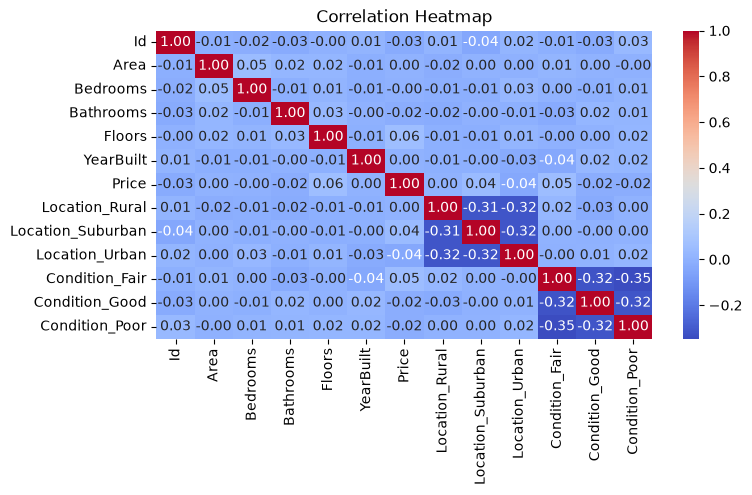

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [11]:
price_correlation = correlation_matrix["Price"].sort_values(ascending=False)

print(price_correlation)

Price                1.000000
Floors               0.055890
Condition_Fair       0.049218
Location_Suburban    0.040303
YearBuilt            0.004845
Location_Rural       0.001890
Area                 0.001542
Bedrooms            -0.003471
Bathrooms           -0.015737
Condition_Good      -0.017179
Condition_Poor      -0.018437
Id                  -0.025643
Location_Urban      -0.038312
Name: Price, dtype: float64


In [12]:
from sklearn.model_selection import train_test_split

# Remove Id because it is only an identifier
X = df.drop(columns=["Id", "Price"])
y = df["Price"]

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1600, 12)
Testing set: (400, 12)


## Train/Test Split

The dataset was divided into training and testing sets using an **80/20 split**.

- **80%** of the data is used for training the machine learning model.
- **20%** of the data is used for evaluating the model on unseen data.
- The **Id** column was excluded because it is only an identifier.
- **Price** is the target variable, while the remaining selected features are used as predictors.
- `random_state=42` was used to ensure reproducibility.

In [13]:
from sklearn.linear_model import LinearRegression

In [15]:
model = LinearRegression()

In [17]:
X_train.dtypes

Area                 int64
Bedrooms             int64
Bathrooms            int64
Floors               int64
YearBuilt            int64
Garage                 str
Location_Rural        bool
Location_Suburban     bool
Location_Urban        bool
Condition_Fair        bool
Condition_Good        bool
Condition_Poor        bool
dtype: object

In [22]:
X['Garage'] = X['Garage'].map({'No': 0, 'Yes': 1})


In [25]:
# Fill missing Garage values with 0
X['Garage'] = X['Garage'].fillna(0)

# Convert Yes/No to 1/0 if they exist
X['Garage'] = X['Garage'].map({'No': 0, 'Yes': 1}).fillna(X['Garage'])

print(X['Garage'].unique())

[0.]


In [26]:
X_train.dtypes

Area                 int64
Bedrooms             int64
Bathrooms            int64
Floors               int64
YearBuilt            int64
Garage                 str
Location_Rural        bool
Location_Suburban     bool
Location_Urban        bool
Condition_Fair        bool
Condition_Good        bool
Condition_Poor        bool
dtype: object

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model trained successfully!")

Model trained successfully!


In [29]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MSE: 78311712968.12479
RMSE: 279842.30017659016
R² Score: -0.006592444359161842


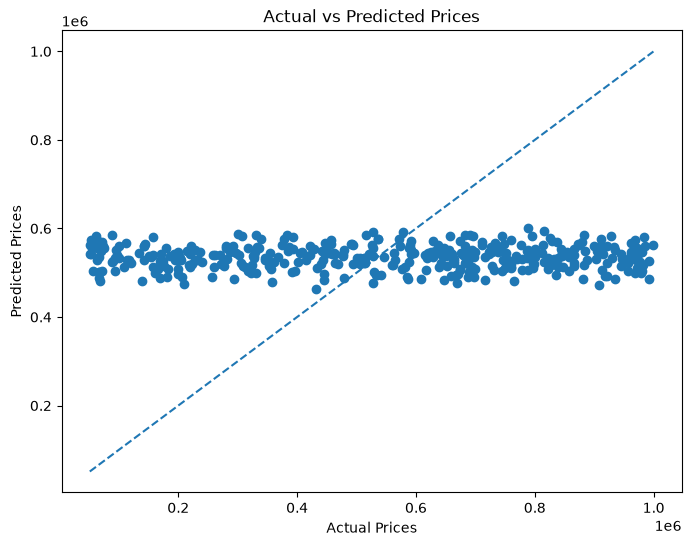

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

# Diagonal reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.show()

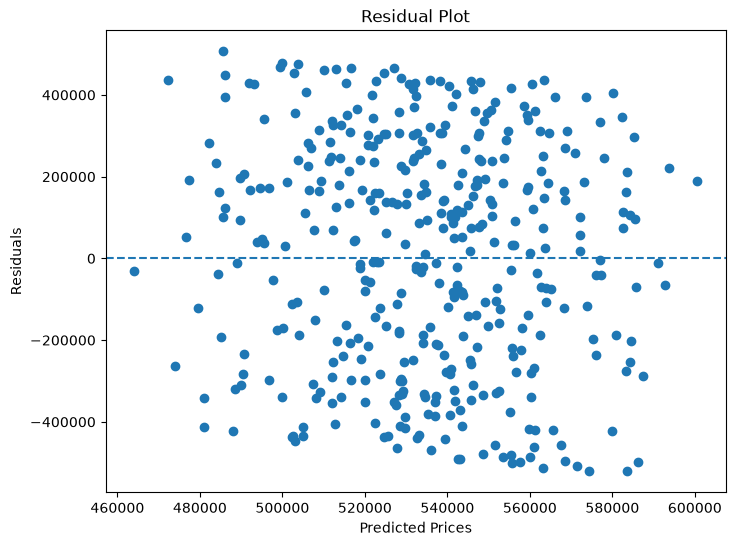

In [31]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [32]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

coefficients

,Feature,Coefficient
9,Condition_Fair,2.421521e+04
3,Floors,2.368970e+04
7,Location_Suburban,1.168082e+04
11,Condition_Poor,4.171921e+03
6,Location_Rural,1.480624e+03
4,YearBuilt,1.170862e+02
1,Bedrooms,2.466412e+01
5,Garage,3.637979e-12
0,Area,-5.887401e-01
2,Bathrooms,-9.645079e+03


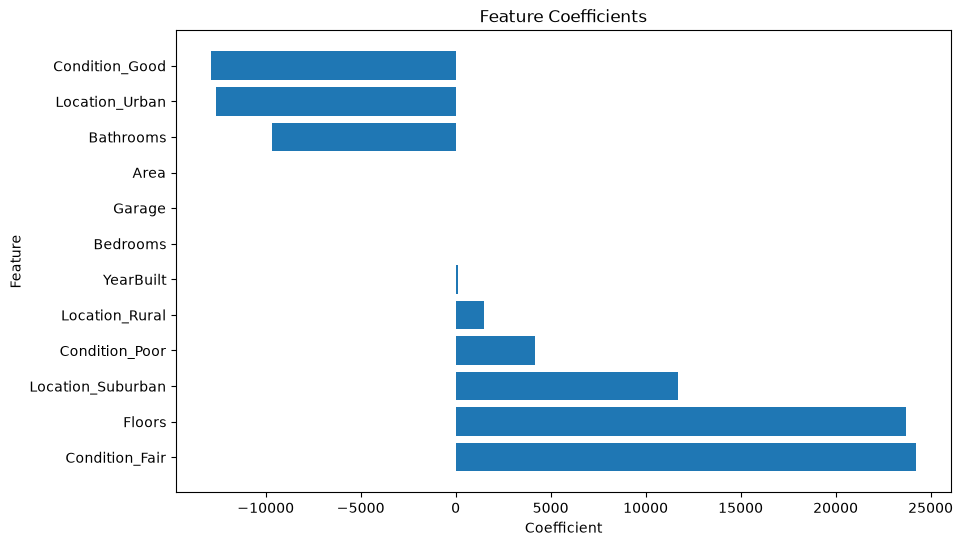

In [33]:
plt.figure(figsize=(10, 6))

plt.barh(
    coefficients['Feature'],
    coefficients['Coefficient']
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Feature Coefficients")

plt.show()

In [34]:
coefficients.head()

,Feature,Coefficient
9,Condition_Fair,24215.208033
3,Floors,23689.698717
7,Location_Suburban,11680.817501
11,Condition_Poor,4171.920970
6,Location_Rural,1480.623686


In [35]:
coefficients.tail()

,Feature,Coefficient
5,Garage,3.637979e-12
0,Area,-5.887401e-01
2,Bathrooms,-9.645079e+03
8,Location_Urban,-1.263867e+04
10,Condition_Good,-1.287022e+04
